In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

import xgboost as xgb


In [ ]:
df = pd.read_csv('/content/sample_data/AB_NYC_2019.csv')

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
print(df.shape)

print(df.info())

print(df.describe())

(48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review         

In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)



In [ ]:
df['last_review'] = df['last_review'].fillna('Unknown')


In [ ]:
df.drop(['id',
         'name',
         'host_name',
         'last_review'],
        axis=1,
        inplace=True)

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df['price'] >= lower) &
        (df['price'] <= upper)]

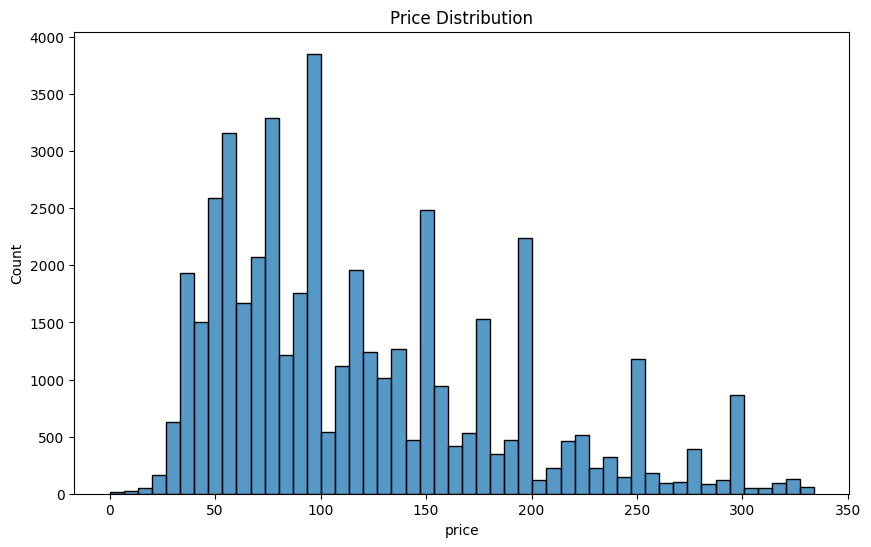

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=50)

plt.title("Price Distribution")
plt.show()

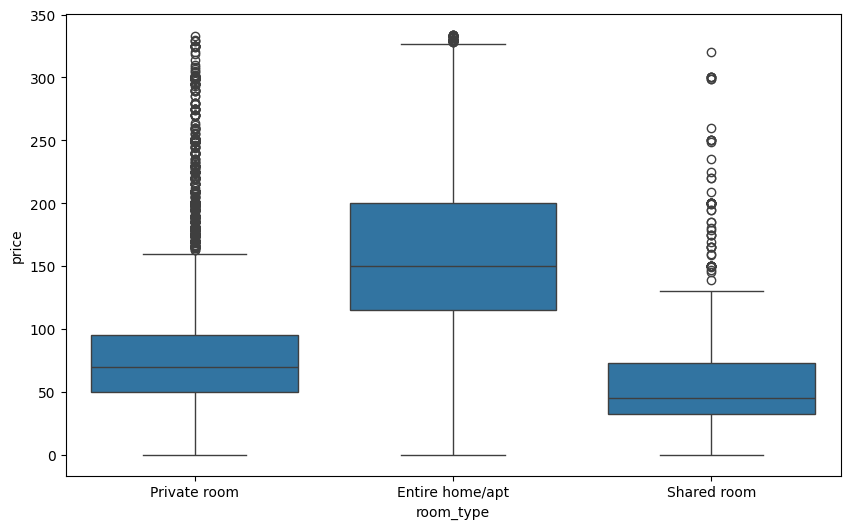

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='room_type',
    y='price',
    data=df
)

plt.show()

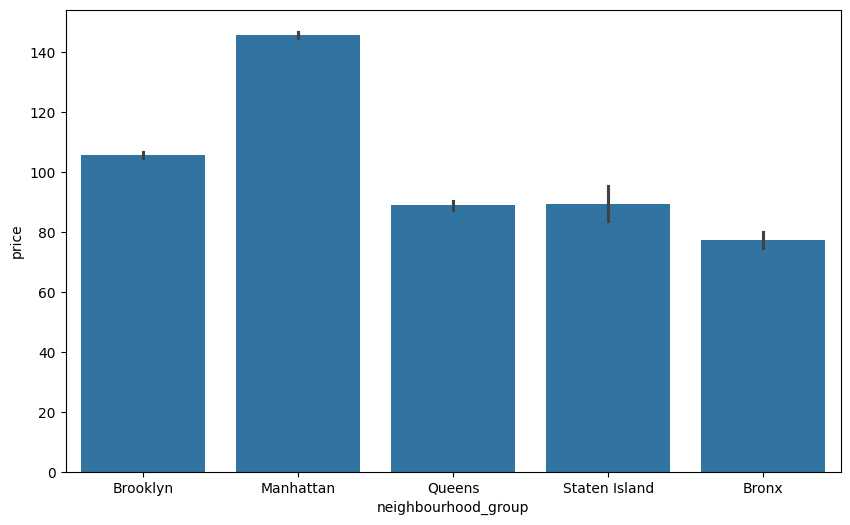

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='neighbourhood_group',
    y='price',
    data=df
)

plt.show()

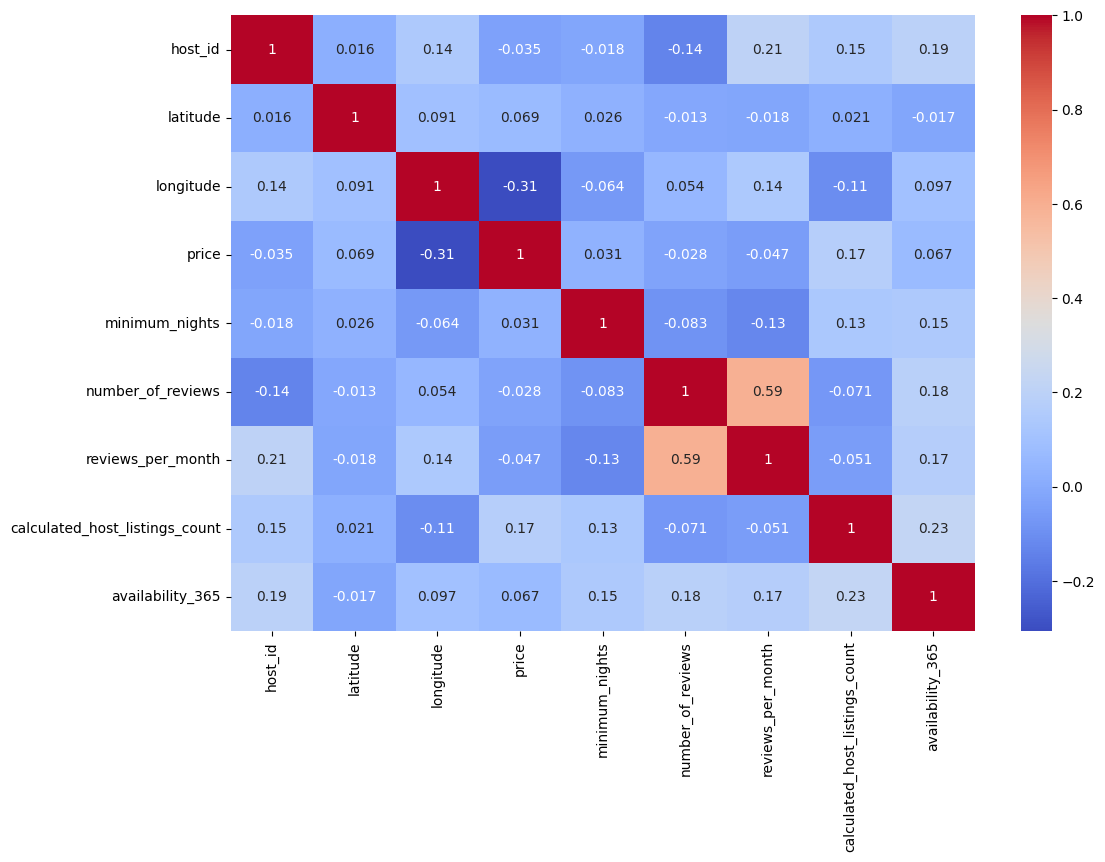

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
le = LabelEncoder()

categorical_cols = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('price', axis=1)

y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
print("Linear Regression")

print("MAE:",
      mean_absolute_error(y_test,pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2:",
      r2_score(y_test,pred_lr))

Linear Regression
MAE: 38.2090469769058
RMSE: 51.10738506365732
R2: 0.4392834765517417


In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [ ]:
print("Random Forest")

print("MAE:",
      mean_absolute_error(y_test,pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2:",
      r2_score(y_test,pred_rf))

Random Forest
MAE: 31.43245400108873
RMSE: 44.056017950713525
R2: 0.5833354866233749


In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train,y_train)

pred_xgb = xgb_model.predict(X_test)

In [ ]:
print("XGBoost")

print("MAE:",
      mean_absolute_error(y_test,pred_xgb))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_xgb)))

print("R2:",
      r2_score(y_test,pred_xgb))

XGBoost
MAE: 31.199230194091797
RMSE: 43.62649699705874
R2: 0.5914204120635986


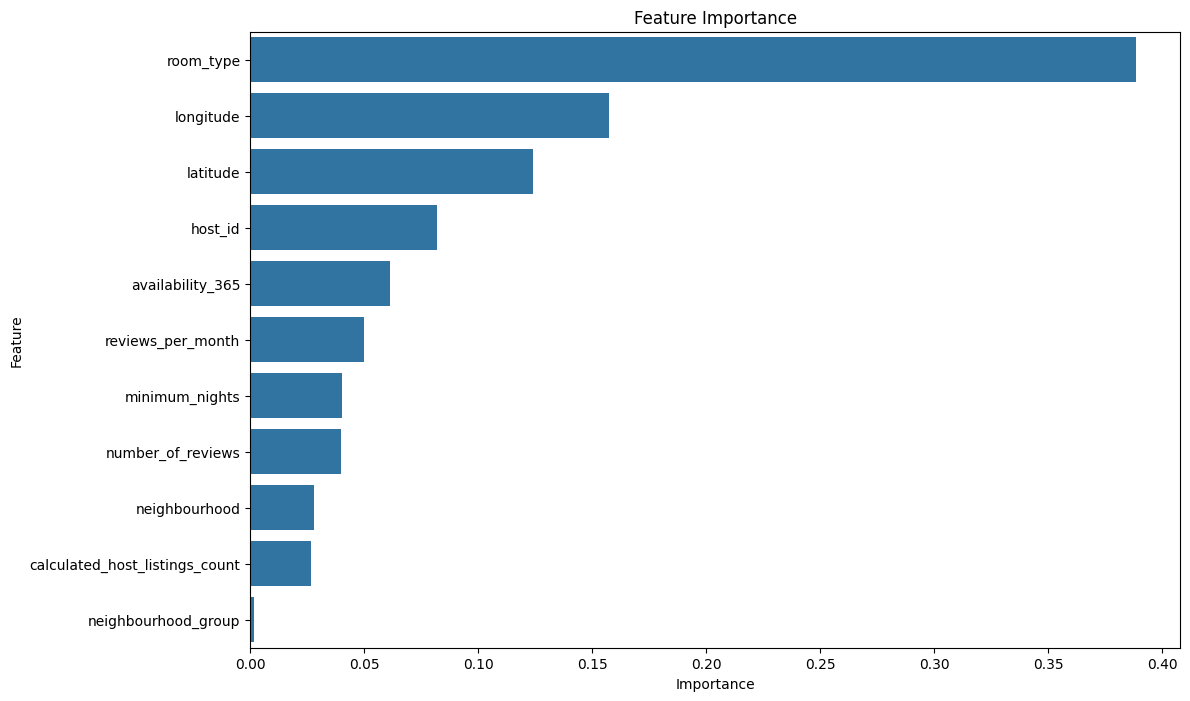

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [ ]:
cluster_data = df[[
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365'
]]

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_data
)

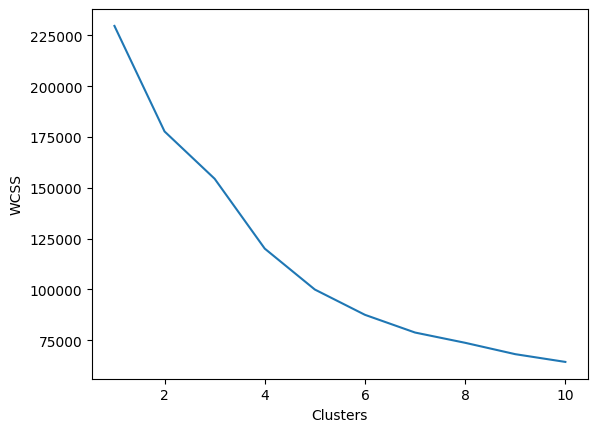

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)

plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(
    scaled_data
)

df['Cluster'] = clusters

In [ ]:
score = silhouette_score(
    scaled_data,
    clusters
)

print("Silhouette Score:",score)

Silhouette Score: 0.3593640386101962


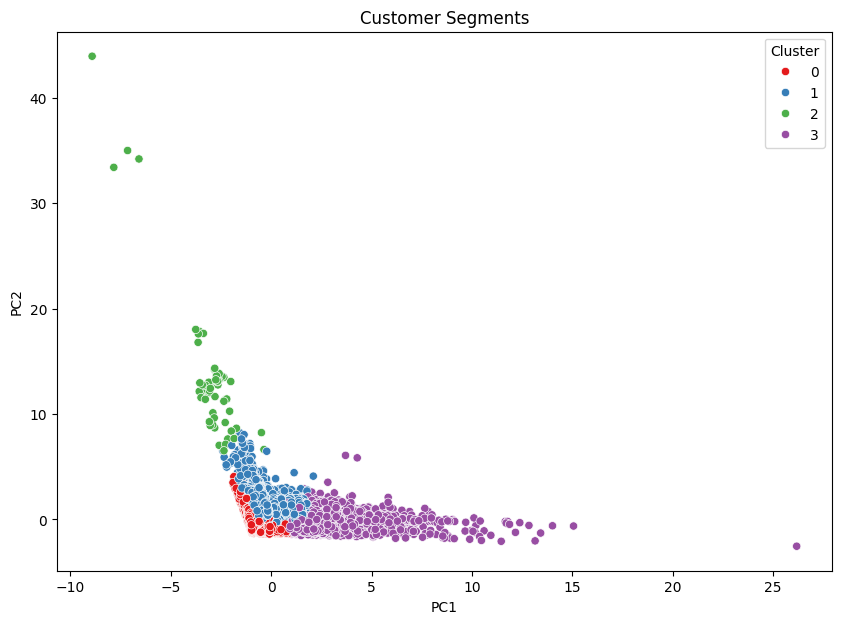

In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = clusters

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segments")

plt.show()

In [ ]:
cluster_profile = df.groupby(
    'Cluster'
).mean()

cluster_profile

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
Cluster,,,,,,,,,,,,
0,5.588224e+07,1.623258,107.648489,40.728817,-73.953711,0.527982,116.128502,4.841096,8.695394,0.522554,2.110239,21.974035
1,8.702948e+07,1.750932,104.301236,40.728263,-73.948841,0.525068,133.508299,12.292768,14.689194,0.809322,19.734587,287.043106
2,3.970479e+07,1.734375,112.343750,40.731754,-73.972941,0.328125,131.312500,385.812500,7.281250,0.183594,1.578125,221.265625
3,7.252680e+07,1.701165,99.578947,40.727529,-73.941849,0.538700,111.740380,2.471620,101.503317,3.988421,2.100251,150.411912


In [ ]:
df['estimated_revenue'] = (
    df['price'] *
    (365 - df['availability_365'])
)

In [ ]:
# Linear Regression Metrics
lr_r2 = r2_score(y_test, pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, pred_lr))

# Random Forest Metrics
rf_r2 = r2_score(y_test, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))

# XGBoost Metrics
xgb_r2 = r2_score(y_test, pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'R2': [
        lr_r2,
        rf_r2,
        xgb_r2
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

results

,Model,R2,RMSE
0,Linear Regression,0.439283,51.107385
1,Random Forest,0.583335,44.056018
2,XGBoost,0.591420,43.626497


In [ ]:
lr_mae = mean_absolute_error(y_test, pred_lr)
rf_mae = mean_absolute_error(y_test, pred_rf)
xgb_mae = mean_absolute_error(y_test, pred_xgb)

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        xgb_r2
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        xgb_mae
    ]
})

results.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,RMSE,MAE
2,XGBoost,0.591420,43.626497,31.199230
1,Random Forest,0.583335,44.056018,31.432454
0,Linear Regression,0.439283,51.107385,38.209047


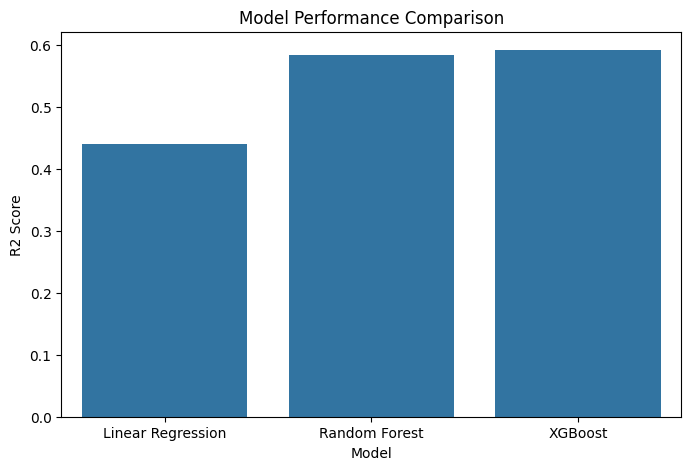

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title('Model Performance Comparison')
plt.show()